In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)


In [27]:
df_raw = pd.read_csv("D:/2022-2026/Project-Data Analysis/DA_Ranked/data/raw/olist_seller.csv")
df = df_raw.copy()

In [28]:
df.head()

,seller_id,seller_city,seller_state,total_revenue,order_count,num_categories,avg_delivery_days,avg_review_score,late_shipping_percentage,cancellation_percentage,repeat_customer_percentage,recency_days
0,0015a82c2db000af6aaaf3ae2ecb0532,santo andre,SP,2748.06,3,1,10,3.67,0.00,0.0,0.0,364
1,001cca7ae9ae17fb1caed9dfb1094831,cariacica,ES,33142.90,195,11,13,3.91,5.56,0.0,0.0,97
2,002100f778ceb8431b7a1020ff7ab48f,franca,SP,1995.16,50,24,16,4.04,16.67,0.0,0.0,188
3,003554e2dce176b5555353e4f3555ac8,goiania,GO,139.38,1,1,4,5.00,0.00,0.0,0.0,306
4,004c9cd9d87a3c30c522c48c4fc07416,ibitinga,SP,23094.02,156,87,14,4.13,7.74,0.0,0.0,167


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2970 entries, 0 to 2969
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   seller_id                   2970 non-null   object 
 1   seller_city                 2970 non-null   object 
 2   seller_state                2970 non-null   object 
 3   total_revenue               2970 non-null   float64
 4   order_count                 2970 non-null   int64  
 5   num_categories              2970 non-null   int64  
 6   avg_delivery_days           2970 non-null   int64  
 7   avg_review_score            2958 non-null   float64
 8   late_shipping_percentage    2970 non-null   float64
 9   cancellation_percentage     2970 non-null   float64
 10  repeat_customer_percentage  2970 non-null   float64
 11  recency_days                2970 non-null   int64  
dtypes: float64(5), int64(4), object(3)
memory usage: 278.6+ KB


In [30]:
df.describe()

,total_revenue,order_count,num_categories,avg_delivery_days,avg_review_score,late_shipping_percentage,cancellation_percentage,repeat_customer_percentage,recency_days
count,2970.000000,2970.000000,2970.000000,2970.000000,2958.000000,2970.000000,2970.0,2970.0,2970.000000
mean,5191.843013,32.935690,11.332997,11.750505,4.122863,8.371909,0.0,0.0,178.729630
std,15938.704241,105.407111,24.532721,7.127575,0.809695,17.013030,0.0,0.0,163.491502
min,15.220000,1.000000,1.000000,1.000000,1.000000,0.000000,0.0,0.0,49.000000
25%,281.582500,2.000000,2.000000,8.000000,3.860000,0.000000,0.0,0.0,62.000000
50%,1038.625000,7.000000,4.000000,11.000000,4.250000,0.000000,0.0,0.0,91.000000
75%,4158.542500,22.000000,10.000000,14.000000,4.670000,10.000000,0.0,0.0,254.750000
max,247007.060000,1819.000000,394.000000,190.000000,5.000000,100.000000,0.0,0.0,744.000000


- Hệ thống có tổng cộng $2970 nhà bán hàng, nhưng phần lớn là các cửa hàng nhỏ lẻ. Một nửa số shop chỉ có chưa tới 7 đơn hàng và thu về khoảng $1038 đơn vị tiền tệ. Trong khi đó, những cửa hàng lớn ở top đầu có thể bán tới 1819 đơn hàng và thu về hơn $247007.
- Hầu hết nhà bán hàng chỉ tập trung vào 1 đến 2 loại mặt hàng thế mạnh của mình.
- Trung bình khách hàng có thể nhận hàng sau khoảng 8 ngày.
- Nhiều nhà bán hàng đã không phát sinh bất kỳ một đơn hàng mới nào suốt vài tháng, thậm chí có những shop không bán trong khoảng 2 năm.


In [31]:
one_order = (df['order_count'] == 1).sum()
print(one_order)

535


- Có 535 seller chỉ bán 1 đơn hàng,

### Chuẩn hóa text

In [32]:
def format_city_name(name):
    words = name.lower().strip().split()

    # danh sách từ thường viết thường trong tiếng Brazil 
    stopwords = {"da", "de", "do", "dos", "das", "em"}
    return " ".join([w.capitalize() if w not in stopwords else w for w in words])

df['seller_city'] = df['seller_city'].apply(format_city_name)
df['seller_state'] = df['seller_state'].str.upper().str.strip()


In [33]:
for col in ['seller_city', 'seller_state']:
    print(f"{col} values: {df[col].unique()}\n")


seller_city values: ['Santo Andre' 'Cariacica' 'Franca' 'Goiania' 'Ibitinga' 'Guarulhos'
 'Sao Paulo' 'Belo Horizonte' 'Maringa' 'Sao Bernardo do Campo' 'Pompeia'
 'Curitiba' 'Timoteo' 'Uruacu' 'Catanduva' 'Francisco Beltrao'
 'Mogi das Cruzes' 'Ribeirao Preto / Sao Paulo' 'Londrina'
 'Ribeirao das Neves' 'Americana' 'Natal' 'Contagem' 'Botucatu'
 'Sao Jose do Rio Preto' 'Blumenau' 'Sao Jose dos Campos' 'Ribeirao Pires'
 'Maua' 'Uberlandia' 'Sao Bento do Sul' 'Sorocaba' 'Bombinhas' 'Osasco'
 'Ivoti' 'Cosmopolis' 'Santo Antonio de Padua' 'Lajeado' 'Rodeio'
 'Itajobi' 'Queimados' 'Criciuma' 'Rio de Janeiro' 'Barueri' 'Alfenas'
 'Sao Paulo - Sp' 'Santo Angelo' 'Paincandu' 'Foz do Iguacu' 'Sao Luis'
 'Porto Alegre' 'Joao Pessoa' 'Saquarema' 'Ribeirao Preto' 'Vespasiano'
 'Taubate' 'Ferraz de Vasconcelos' 'Cananeia' 'Itapevi' 'Uba' 'Cascavel'
 'Marilia' 'Santos' 'Canoas' 'Taboao da Serra' 'Jundiai' 'Louveira' 'Sp'
 'Sao Roque' 'Teixeira Soares' 'Jaragua do Sul' 'Aruja' 'Itajai'
 'Valinhos' 

In [34]:
city_mapping = {
    # Sao Paulo
    'Sao Paulo - Sp': 'Sao Paulo',
    'Sao Paulo Sp': 'Sao Paulo',
    'Sao Paulo / Sao Paulo': 'Sao Paulo',
    'Sao Paulop': 'Sao Paulo',
    'Sao Paluo': 'Sao Paulo',
    'Sp': 'Sao Paulo',
    'Sp / Sp': 'Sao Paulo',
    'São Paulo': 'Sao Paulo',

    # Santo Andre
    'Sando Andre': 'Santo Andre',
    'Santo Andre/sao Paulo': 'Santo Andre',

    # Sao Bernardo
    'Ao Bernardo do Campo': 'Sao Bernardo do Campo',
    'Sao Bernardo do Capo': 'Sao Bernardo do Campo',
    'Sbc/sp': 'Sao Bernardo do Campo',

    # Ribeirao Preto
    'Riberao Preto': 'Ribeirao Preto',
    'Robeirao Preto': 'Ribeirao Preto',
    'Ribeirao Pretp': 'Ribeirao Preto',
    'Ribeirao Preto / Sao Paulo': 'Ribeirao Preto',

    # Sao Jose do Rio Preto
    'Sao Jose do Rio Pret': 'Sao Jose do Rio Preto',
    'S Jose do Rio Preto': 'Sao Jose do Rio Preto',

    # Mogi das Cruzes
    'Mogi das Cruses': 'Mogi das Cruzes',
    'Mogi das Cruzes / Sp': 'Mogi das Cruzes',

    # Rio de Janeiro
    'Rio de Janeiro \\rio de Janeiro': 'Rio de Janeiro',
    'Rio de Janeiro / Rio de Janeiro': 'Rio de Janeiro',
    'Rio de Janeiro, Rio de Janeiro, Brasil': 'Rio de Janeiro',

    # Novo Hamburgo
    'Novo Hamburgo, Rio Grande do Sul, Brasil': 'Novo Hamburgo',

    # Cariacica
    'Cariacica / Es': 'Cariacica',

    # Jacarei
    'Jacarei / Sao Paulo': 'Jacarei',

    # Maua
    'Maua/sao Paulo': 'Maua',

    # Pinhais
    'Pinhais/pr': 'Pinhais',

    # Lages
    'Lages - Sc': 'Lages',

    # Angra
    'Angra dos Reis Rj': 'Angra dos Reis'
}

df['seller_city'] = df['seller_city'].replace(city_mapping)

In [35]:
for col in df.select_dtypes(include='object').columns:
    print(f"{col}: {df[col].nunique()} unique values")

seller_id: 2970 unique values
seller_city: 561 unique values
seller_state: 22 unique values


- có 2970 nhà bán hàng
- các nhà bán hàng này phân bố trên 561 thành phố và 22 bang

### Chuyển đổi kiểu dữ liệu

In [36]:
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype('category')

### Xử lý duplicate

In [37]:
df.duplicated().sum()

0

In [38]:
df.duplicated(
    subset=['seller_id','seller_city','seller_state']
).sum()

0

### Xử lý missing

In [39]:
df.isna().sum()

seller_id                      0
seller_city                    0
seller_state                   0
total_revenue                  0
order_count                    0
num_categories                 0
avg_delivery_days              0
avg_review_score              12
late_shipping_percentage       0
cancellation_percentage        0
repeat_customer_percentage     0
recency_days                   0
dtype: int64

In [40]:
df_missing = df.copy()
df_missing['revenue_group'] = pd.qcut(
    df_missing['total_revenue'],
    q=5,
    duplicates='drop'
)

(
    df_missing.groupby('revenue_group')['avg_review_score']
      .apply(lambda x: x.isna().mean()*100)
)

revenue_group
(15.219000000000001, 213.906]    1.683502
(213.906, 648.83]                0.168350
(648.83, 1643.318]               0.000000
(1643.318, 5560.462]             0.000000
(5560.462, 247007.06]            0.168350
Name: avg_review_score, dtype: float64

In [41]:
df[df['avg_review_score'].isna()].head(12)

,seller_id,seller_city,seller_state,total_revenue,order_count,num_categories,avg_delivery_days,avg_review_score,late_shipping_percentage,cancellation_percentage,repeat_customer_percentage,recency_days
36,0336182e1b3e92f029d5354832045fdf,Ibitinga,SP,47.37,1,2,13,NaN,0.0,0.0,0.0,742
363,1fa2d3def6adfa70e58c276bb64fe5bb,Sao Paulo,SP,15.90,1,1,6,NaN,0.0,0.0,0.0,54
382,20f0aeea30bc3b8c4420be8ced4226c0,Santa Barbara D'oeste,SP,29.42,1,1,45,NaN,100.0,0.0,0.0,619
673,3a79f35a2344ede41af21267f61d5ec6,Campinas,SP,217.71,1,1,14,NaN,0.0,0.0,0.0,335
793,43a5d4a57af536fddc96d08be3afdfcb,Varginha,MG,99.83,1,1,12,NaN,0.0,0.0,0.0,490
995,5415337f1863452476d42d9f14a16a61,Belo Horizonte,MG,68.35,1,1,16,NaN,0.0,0.0,0.0,74
1386,7494d0dcba8551df6cf37f1b905dc2f7,Santos,SP,62.97,1,1,6,NaN,0.0,0.0,0.0,167
1525,80ceebb4ee9b31afb6c6a916a574a1e2,Londrina,PR,6922.21,1,1,21,NaN,100.0,0.0,0.0,84
1733,9315e491484b1b0081ca166fc164108d,Londrina,PR,60.40,1,1,7,NaN,0.0,0.0,0.0,103
2188,bcd2d7510d58e293f20fad6438c1b314,Curitiba,PR,39.46,1,1,33,NaN,100.0,0.0,0.0,615


In [42]:
df_missing['order_group'] = pd.cut(
    df_missing['order_count'],
    bins=[0,10,50,100,500,10000],
    labels=['0-10','11-50','51-100','101-500','500+']
)
(
    df_missing.groupby('order_group')['avg_review_score']
      .apply(lambda x: x.isna().mean()*100)
)

order_group
0-10       0.668896
11-50      0.000000
51-100     0.000000
101-500    0.000000
500+       0.000000
Name: avg_review_score, dtype: float64

In [43]:
df[df['order_count'] == 1].describe()

,total_revenue,order_count,num_categories,avg_delivery_days,avg_review_score,late_shipping_percentage,cancellation_percentage,repeat_customer_percentage,recency_days
count,535.000000,535.0,535.000000,535.000000,523.000000,535.000000,535.0,535.0,535.000000
mean,276.567383,1.0,1.016822,13.089720,4.075048,9.719626,0.0,0.0,286.549533
std,626.505246,0.0,0.166752,12.288335,1.347840,29.650206,0.0,0.0,205.400625
min,15.220000,1.0,1.000000,1.000000,1.000000,0.000000,0.0,0.0,50.000000
25%,62.625000,1.0,1.000000,7.000000,3.000000,0.000000,0.0,0.0,102.500000
50%,119.700000,1.0,1.000000,11.000000,5.000000,0.000000,0.0,0.0,226.000000
75%,224.600000,1.0,1.000000,15.500000,5.000000,0.000000,0.0,0.0,452.000000
max,6929.310000,1.0,4.000000,190.000000,5.000000,100.000000,0.0,0.0,744.000000


**Insight**
- Những cửa hàng thiếu điểm đánh giá đa phần là cửa hàng nhỏ, hoạt động kém, ít đơn hàng.
- Missing tập trung ở doanh thu thấp và đơn hàng nhỏ - seller mới hoặc seller có ít đơn hàng thường chưa nhận được review từ khách hàng.
- Missing phụ thuộc vào quy mô seller không phải thiếu ngẫu nhiên, nên đây là `MAR`.

**Action**
- Tất cả 12 dòng missing đều có order_count = 1 và std của avg_review_score ở nhóm order=1 rất cao (1.53), std này cho thấy điểm đánh giá của những người bán chỉ có 1 đơn hàng là phân tán: có người được 5 sao, có người chỉ 1 sao. Không có sự tập trung quanh một giá trị nào.
- Vì vậy cần tạo cờ lưu các bản ghi thiếu, không xóa các bản ghi này.
- Điền giá trị -1 để nhận biết seller chưa có đánh giá

In [44]:
df['has_review'] = np.where(df['avg_review_score'].isna(), 0, 1)
df['avg_review_score'] = df['avg_review_score'].fillna(-1)

### Kiểm tra lỗi logic kinh doanh

- Kiểm tra điểm đánh gia có âm không

In [45]:
df_filtered = df[df['avg_review_score'] != -1]

# Kiểm tra số lượng giá trị âm còn lại
neg_score = (df_filtered['avg_review_score'] < 0).sum()
print(neg_score)


0


- Tỷ lệ giao hàng trễ có vượt ra ngoài khoảng 0–100% không

In [46]:
invalid_shipping = (df['late_shipping_percentage'] < 0) | (df['late_shipping_percentage'] > 100)
print(invalid_shipping.sum())



0


- Có seller nào bán hàng mà không có danh mục sản phẩm không.

In [47]:
cat_zero = (df['num_categories'] == 0).sum()
print(cat_zero)

0


- Thời gian giao hàng trung bình có thể âm không

In [48]:
day_zero = (df['avg_delivery_days'] < 0).sum()
print(day_zero)

0


### Xử lý outlier

In [49]:
def outlier(col):
    q1 = col.quantile(0.25)
    q3 = col.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    # in tỷ lệ outliers từng cột
    outlier_percentage = ((col < lower_bound) | (col > upper_bound)).mean() * 100
    return outlier_percentage

df_otl = df[df['has_review'] == 1].copy() # loại bản ghi của avg_review_score có missing
outliers = outlier(df_otl.select_dtypes(include=np.number))
print(outliers)

total_revenue                 11.528059
order_count                   13.590264
num_categories                11.899932
avg_delivery_days              4.259635
avg_review_score               5.780933
late_shipping_percentage       8.113590
cancellation_percentage        0.000000
repeat_customer_percentage     0.000000
recency_days                   5.206220
has_review                     0.000000
dtype: float64


In [50]:
df_otl.describe()


,total_revenue,order_count,num_categories,avg_delivery_days,avg_review_score,late_shipping_percentage,cancellation_percentage,repeat_customer_percentage,recency_days,has_review
count,2958.000000,2958.000000,2958.000000,2958.000000,2958.000000,2958.000000,2958.0,2958.0,2958.000000,2958.0
mean,5210.287062,33.065247,11.374577,11.730899,4.122863,8.304452,0.0,0.0,178.265044,1.0
std,15967.919970,105.601100,24.573735,7.100034,0.809695,16.789346,0.0,0.0,162.913491,0.0
min,15.220000,1.000000,1.000000,1.000000,1.000000,0.000000,0.0,0.0,49.000000,1.0
25%,284.907500,2.000000,2.000000,8.000000,3.860000,0.000000,0.0,0.0,62.000000,1.0
50%,1047.880000,7.000000,4.000000,11.000000,4.250000,0.000000,0.0,0.0,91.000000,1.0
75%,4163.817500,22.000000,10.000000,14.000000,4.670000,10.000000,0.0,0.0,254.000000,1.0
max,247007.060000,1819.000000,394.000000,190.000000,5.000000,100.000000,0.0,0.0,744.000000,1.0


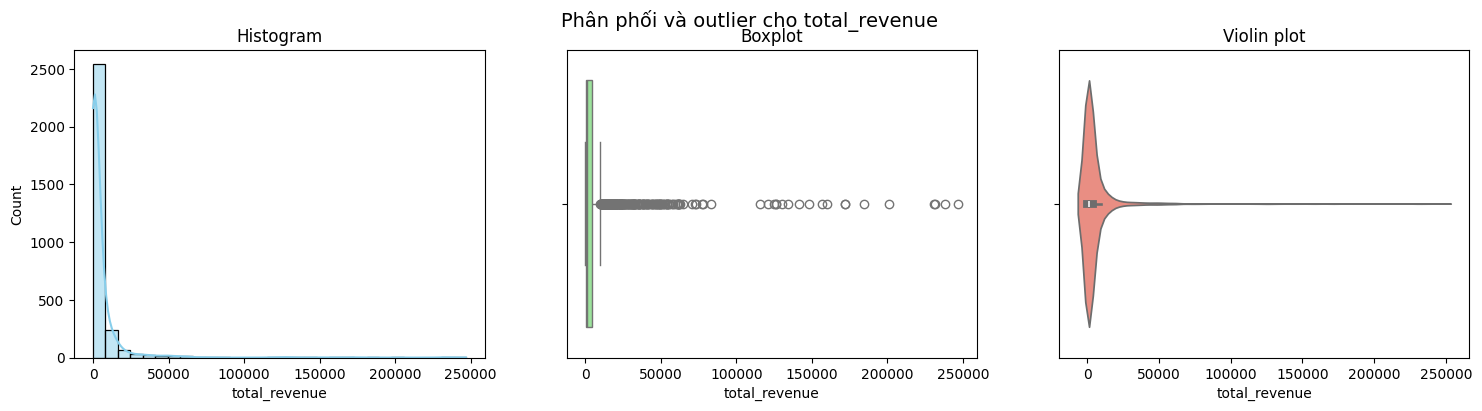

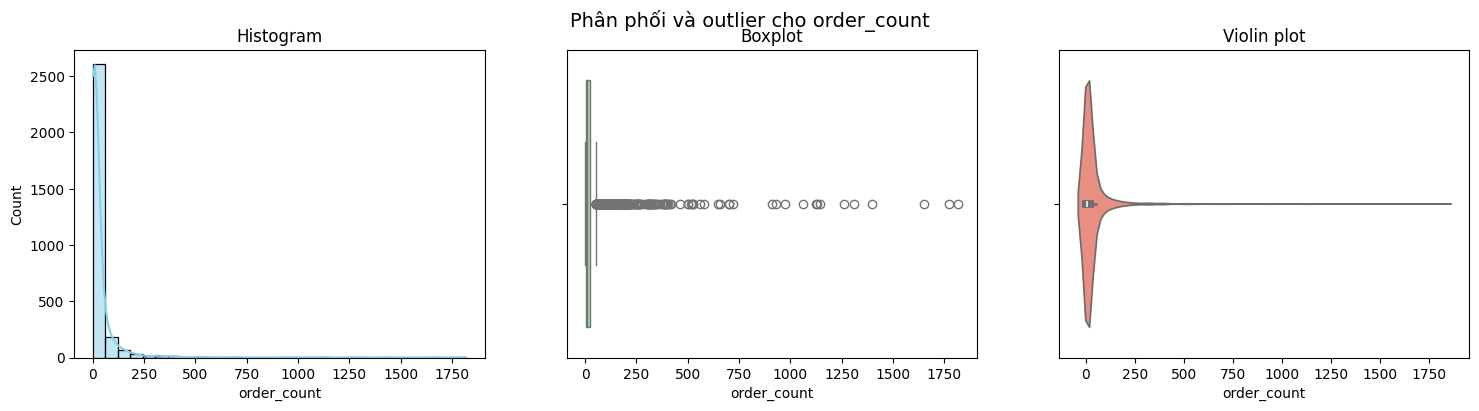

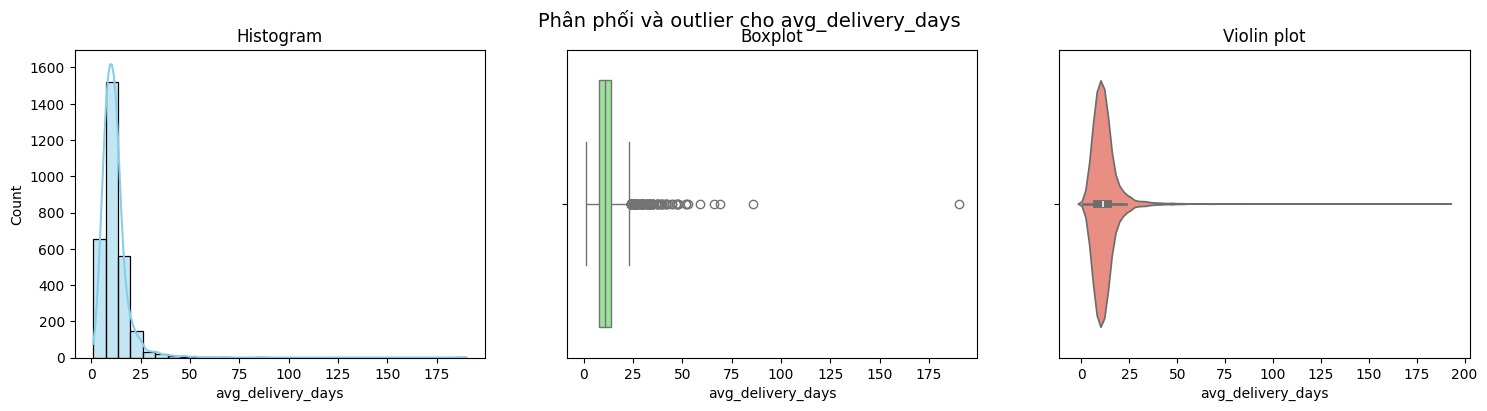

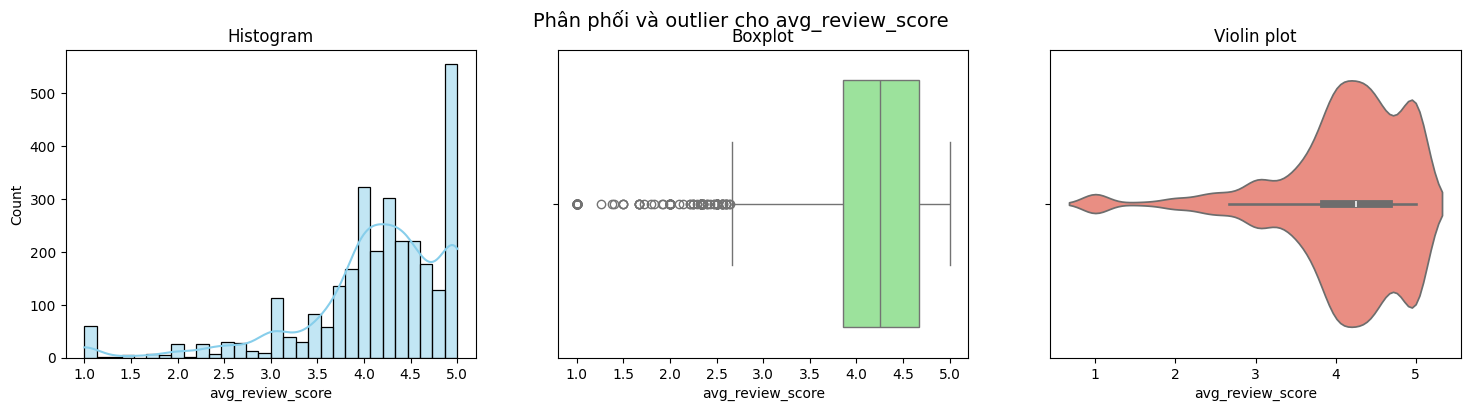

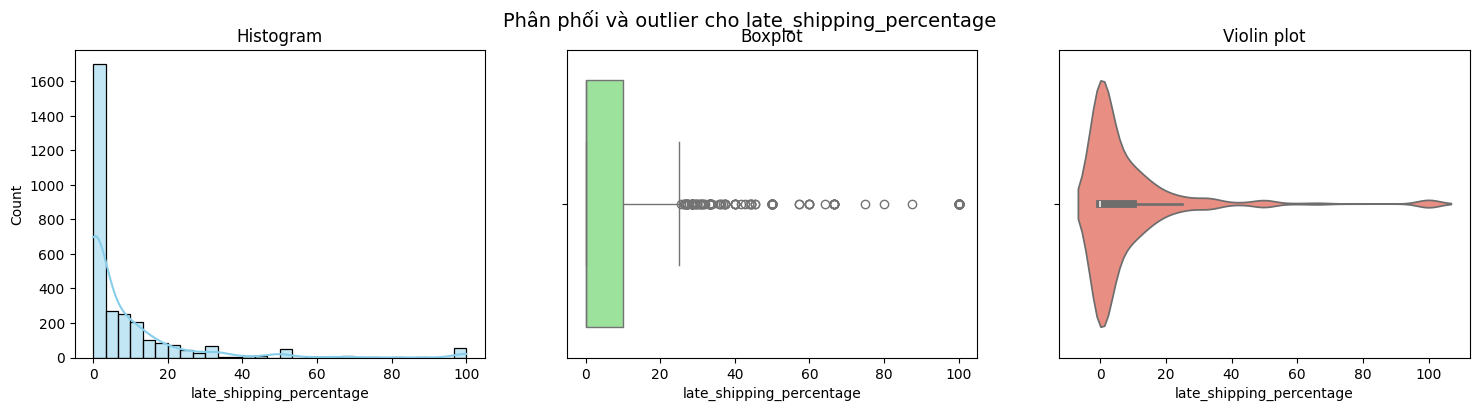

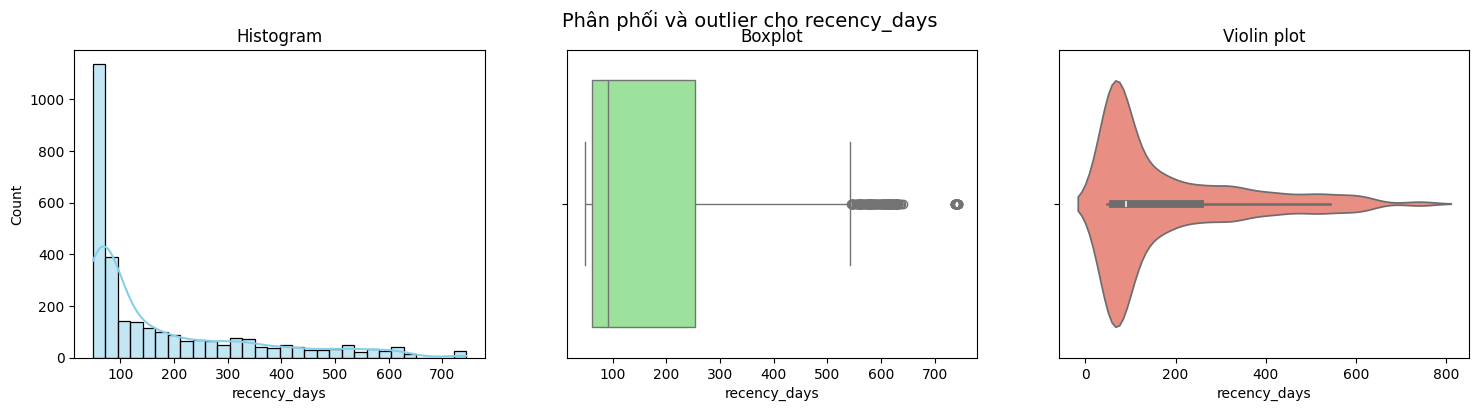

In [51]:
outlier_cols = ['total_revenue', 'order_count', 'avg_delivery_days', 
                'avg_review_score', 'late_shipping_percentage', 'recency_days']

for col in outlier_cols:
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    fig.suptitle(f"Phân phối và outlier cho {col}", fontsize=14)

    # 1. Histogram
    sns.histplot(df_otl[col], bins=30, kde=True, ax=axes[0], color="skyblue")
    axes[0].set_title("Histogram")

    # 2. Boxplot 
    sns.boxplot(x=df_otl[col], ax=axes[1], color="lightgreen")
    axes[1].set_title("Boxplot")

    # 3. Violin plot (phân phối + mật độ)
    sns.violinplot(x=df_otl[col], ax=axes[2], color="salmon")
    axes[2].set_title("Violin plot")

    plt.show() 

**Insight**

- total_revenue: phân phối lệch phải, các điểm outlier tập trung ở khoảng 10.000 đến 250.000. Phần lớn doanh thu của sàn đến từ một nhóm nhỏ các seller lớn. 

- order_count: cũng phân phố lệch phải, số lượng đơn hàng của đại đa số các seller chỉ quanh mốc 10-30 đơn. Số lượng seller nhỏ và vừa chiếm đa số ở sàn Olist nhưng số lượng đơn phát sinh lại rất ít.

- avg_delivery_days: phân phối tập trung ở khoảng 0-20 ngày, nhưng cũng có outlier kéo dài rất xa về phía phải, cá biết là 190 ngày. Khoảng thời gian trễ kỷ lục này thường rơi vào các đơn hàng bị thất lạc, hoặc hàng quốc tế, hàng đặt trước. 

- avg_review_score: khác với các biến khác, biến này có phân phối lệch trái mạnh. Đa số sản phẩm đáp ứng nhu cầu của khách hàng

- late_shipping_percentage: Phần lớn người bán trên sàn tuân thủ tốt thời gian chuẩn bị hàng. Tuy nhiên, nhóm outlier có tỷ lệ trễ hạn cao phản ánh các cửa hàng hoạt động kém hiệu quả, thiếu hụt nguồn hàng ...

- recency_days: hầu hết các shop trên sàng đều có phát sinh đơn hàng trong 1.5 năm trở lại đây.

In [52]:
target_cols = [
    "total_revenue",
    "order_count",
    "avg_delivery_days",
    "avg_review_score",
    "late_shipping_percentage",
    "recency_days",
]
context_cols = ["seller_state"]  

def iqr_bounds(col):
    q1 = col.quantile(0.25)
    q3 = col.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return lower, upper


for col in target_cols:
    # b1: tìm global outlier
    lower_g, upper_g = iqr_bounds(df_otl[col])
    global_mask = (df_otl[col] < lower_g) | (df_otl[col] > upper_g)

    # b2: tìm context outlier 
    group_q1 = df_otl.groupby(context_cols)[col].transform("quantile", 0.25)
    group_q3 = df_otl.groupby(context_cols)[col].transform("quantile", 0.75)
    group_iqr = group_q3 - group_q1

    lower_c = group_q1 - 1.5 * group_iqr
    upper_c = group_q3 + 1.5 * group_iqr
    context_mask = (df_otl[col] < lower_c) | (df_otl[col] > upper_c)

    # b3: gán nhãn loại outlier cho từng dòng
    conditions = [
        global_mask, 
        context_mask,
    ]
    choices = ["global", "context"]

    # nếu không thỏa mãn 2 điều kiện trên thì mặc định là 'normal'
    df_otl[f"{col}_outlier_type"] = np.select(conditions, choices, default="normal")

# kết quả
print(df_otl[[c + "_outlier_type" for c in target_cols]].head())

  total_revenue_outlier_type order_count_outlier_type  \
0                     normal                   normal   
1                     global                   global   
2                     normal                   normal   
3                     normal                   normal   
4                     global                   global   

  avg_delivery_days_outlier_type avg_review_score_outlier_type  \
0                         normal                        normal   
1                         normal                        normal   
2                         normal                        normal   
3                         normal                        normal   
4                         normal                        normal   

  late_shipping_percentage_outlier_type recency_days_outlier_type  
0                                normal                    normal  
1                                normal                    normal  
2                                normal                 

In [53]:
def show_outlier_info(df_clean, col, type_col='outlier_type', top_n=20):
    # lấy ra các dòng có outlier
    outlier_df_clean = df_clean[df_clean[type_col] != 'normal'].copy()

    print("=" * 80)
    print(f"{col}")

    # describe
    print("\n[DESCRIBE]")
    print(outlier_df_clean[col].describe())

    # value_counts
    print("\n[VALUE COUNTS]")
    print(outlier_df_clean[col].round(2).value_counts().head(top_n))

    # số lượng từng loại outlier
    print("\n[OUTLIER COUNTS]")
    print(outlier_df_clean[type_col].value_counts())

show_outlier_info(df_otl, 'total_revenue', 'total_revenue_outlier_type')
show_outlier_info(df_otl, 'order_count', 'order_count_outlier_type')
show_outlier_info(df_otl, 'avg_delivery_days', 'avg_delivery_days_outlier_type')
show_outlier_info(df_otl, 'avg_review_score', 'avg_review_score_outlier_type')
show_outlier_info(df_otl, 'late_shipping_percentage', 'late_shipping_percentage_outlier_type')
show_outlier_info(df_otl, 'recency_days', 'recency_days_outlier_type')



total_revenue

[DESCRIBE]
count       362.000000
mean      30013.808204
std       36746.893004
min        5019.600000
25%       12514.362500
50%       16413.340000
75%       31931.777500
max      247007.060000
Name: total_revenue, dtype: float64

[VALUE COUNTS]
total_revenue
33142.90     1
10140.99     1
10250.20     1
13692.25     1
13284.02     1
15410.66     1
17947.55     1
15352.47     1
11673.20     1
11659.73     1
18672.75     1
14980.43     1
14306.91     1
15928.04     1
15785.77     1
10373.82     1
27865.80     1
16240.83     1
31479.28     1
130412.74    1
Name: count, dtype: int64

[OUTLIER COUNTS]
total_revenue_outlier_type
global     341
context     21
Name: count, dtype: int64
order_count

[DESCRIBE]
count     426.000000
mean      173.199531
std       232.094514
min        15.000000
25%        66.250000
50%        97.000000
75%       167.250000
max      1819.000000
Name: order_count, dtype: float64

[VALUE COUNTS]
order_count
62     9
63     9
77     8
61     8
56     

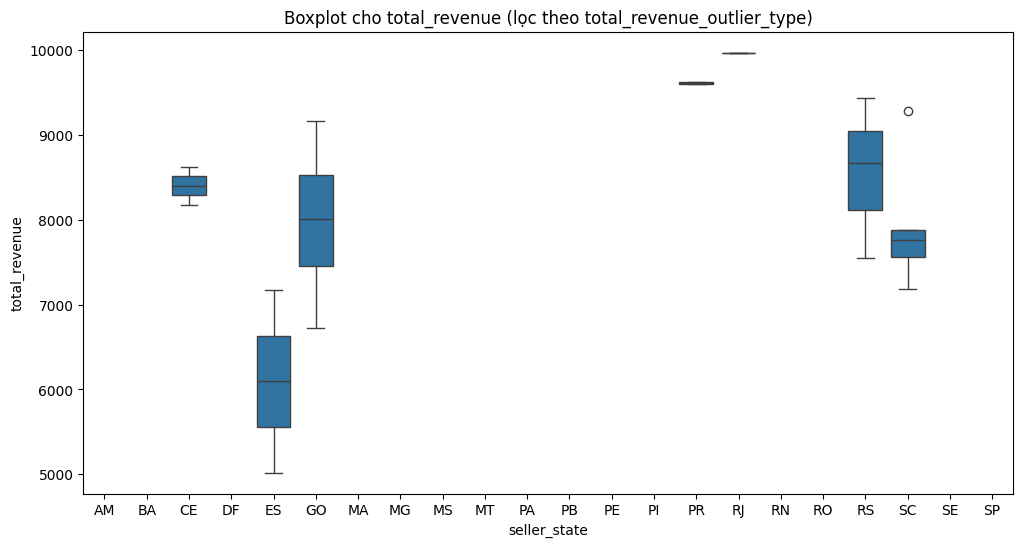

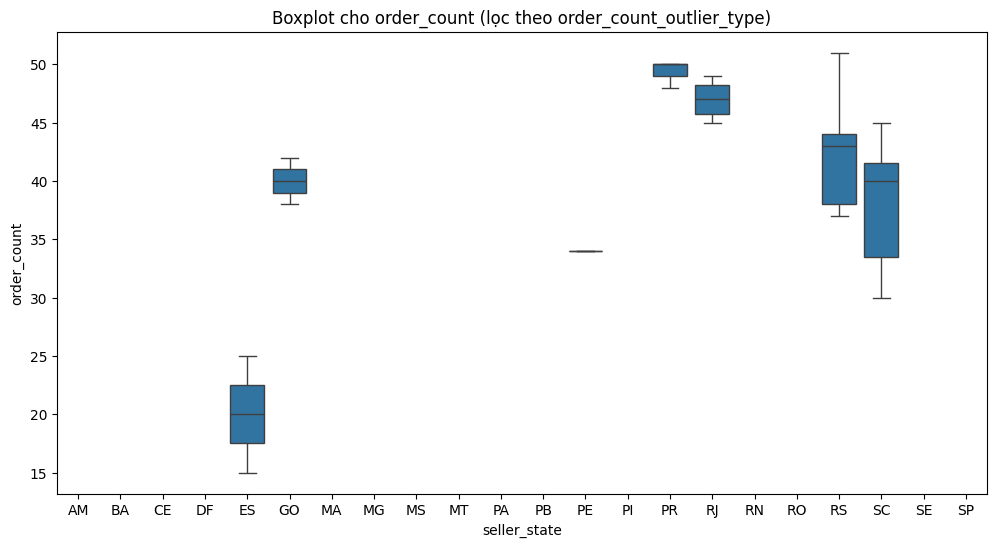

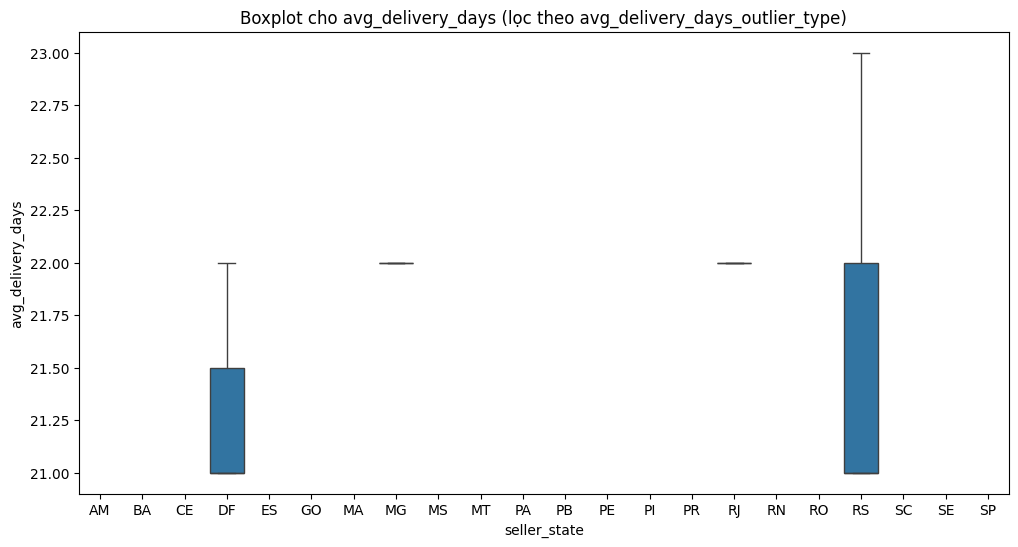

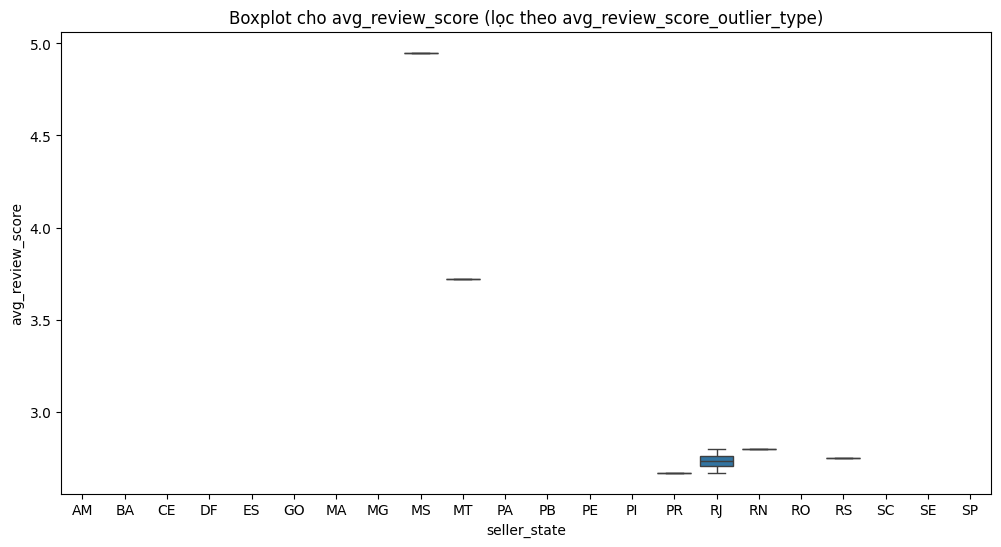

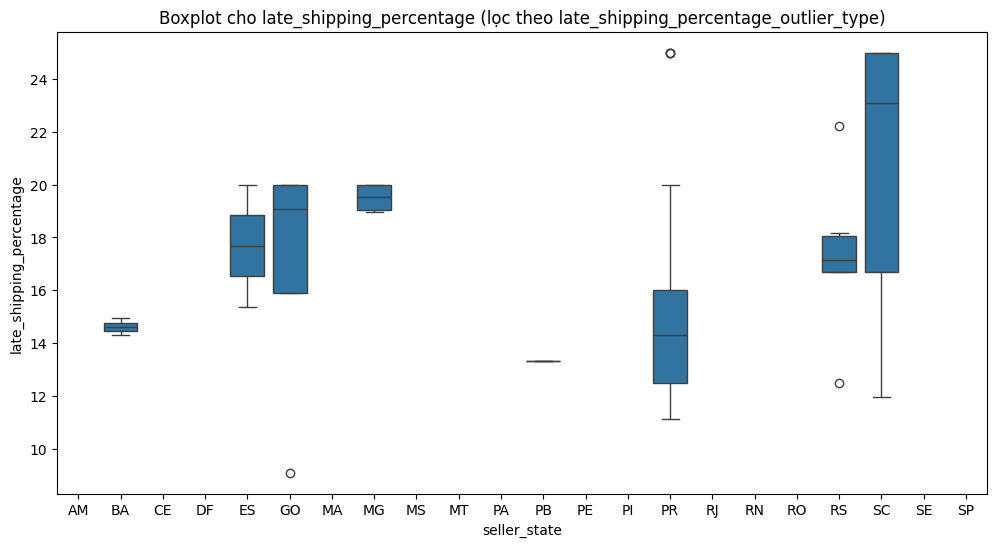

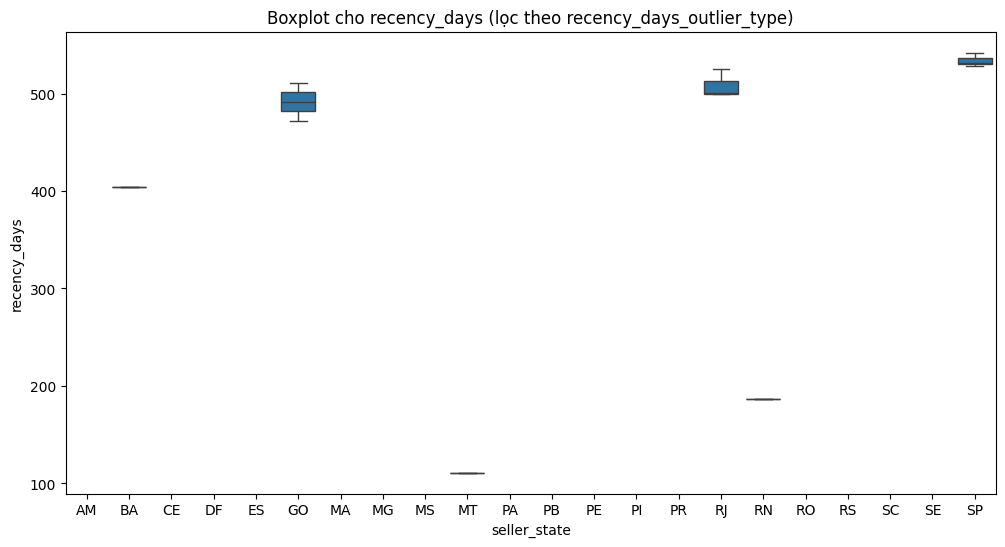

In [54]:

outlier_map = {
    'total_revenue_outlier_type': 'total_revenue',
    'order_count_outlier_type': 'order_count',
    'avg_delivery_days_outlier_type': 'avg_delivery_days',
    'avg_review_score_outlier_type': 'avg_review_score',
    'late_shipping_percentage_outlier_type': 'late_shipping_percentage',
    'recency_days_outlier_type': 'recency_days'
}

# Lặp qua từng biến outlier
for var, numeric_col in outlier_map.items():
    context_df = df_otl[df_otl[var] == 'context']

    plt.figure(figsize=(12,6))
    sns.boxplot(
        data=context_df,
        x='seller_state',  
        y=numeric_col   # dùng cột số gốc thay vì cột outlier_type
    )
    plt.title(f'Boxplot cho {numeric_col} (lọc theo {var})')
    plt.show()


**Insight**
- Nhóm global: những cửa hàng có số liệu vượt trội hoặc tệ hơn hẳn so với quy chuẩn của toàn bộ sàn thương mại điện tử. Nhóm này chiếm số lượng áp đảo ở các biến mang tính chất quy mô như doanh thu và số lượng đơn hàng

- Nhóm context: Là những cửa hàng có số liệu bình thường so với toàn sàn, nhưng lại vượt trội hơn trong bối cảnh từng bang. Tuy nhiên các bản ghi context outlier này lại phân bố ở nhiều bang mà không tập trung vào 1 bang, nên đây không phải là `context outlier`.

- Vậy toàn bộ các bản ghi outlier trong 6 cột đều thuộc `global outlieer`

**Action** 
- Giữ lại các bản ghi outlier này. 
- Và gắn flag để theo dõi. 

In [55]:
# for col in target_cols:
#     df[f"{col}_outlier_type"] = df_otl[f'{col}_outlier_type']
#     df[f'{col}_outlier_flag'] = df[f'{col}_outlier_type'] != 'normal'

In [56]:
for col in target_cols:
    df[f"{col}_outlier_type"] = df_otl.get(f'{col}_outlier_type')
    df[f"{col}_outlier_type"] = df[f"{col}_outlier_type"].fillna('missing')
    df[f'{col}_outlier_flag'] = df[f'{col}_outlier_type'] != 'normal'


### Kiểm tra lại trước khi load data đã làm sạch

In [57]:
print("Missing: \n", df.isna().sum())
print("\nDuplicated:", df.duplicated().sum())

Missing: 
 seller_id                                0
seller_city                              0
seller_state                             0
total_revenue                            0
order_count                              0
num_categories                           0
avg_delivery_days                        0
avg_review_score                         0
late_shipping_percentage                 0
cancellation_percentage                  0
repeat_customer_percentage               0
recency_days                             0
has_review                               0
total_revenue_outlier_type               0
total_revenue_outlier_flag               0
order_count_outlier_type                 0
order_count_outlier_flag                 0
avg_delivery_days_outlier_type           0
avg_delivery_days_outlier_flag           0
avg_review_score_outlier_type            0
avg_review_score_outlier_flag            0
late_shipping_percentage_outlier_type    0
late_shipping_percentage_outlier_flag    0


In [58]:
# Loại bỏ các dòng không có review
df_check = df[df['has_review'] == 1].copy()
neg_score = (df_check['avg_review_score'] < 0).sum()
print("Negative review scores:", neg_score)


Negative review scores: 0


In [59]:
# phân phối trước và sau cleaning 
summary_before = df_raw[df_raw.select_dtypes([float, int]).columns].describe().T
summary_after = df_check[df_check.select_dtypes([float, int]).columns].describe().T

print("-- Trước cleaning -- ")
display(summary_before)

print("-- Sau cleaning --")
display(summary_after)

-- Trước cleaning -- 


,count,mean,std,min,25%,50%,75%,max
total_revenue,2970.0,5191.843013,15938.704241,15.22,281.5825,1038.625,4158.5425,247007.06
order_count,2970.0,32.935690,105.407111,1.00,2.0000,7.000,22.0000,1819.00
num_categories,2970.0,11.332997,24.532721,1.00,2.0000,4.000,10.0000,394.00
avg_delivery_days,2970.0,11.750505,7.127575,1.00,8.0000,11.000,14.0000,190.00
avg_review_score,2958.0,4.122863,0.809695,1.00,3.8600,4.250,4.6700,5.00
late_shipping_percentage,2970.0,8.371909,17.013030,0.00,0.0000,0.000,10.0000,100.00
cancellation_percentage,2970.0,0.000000,0.000000,0.00,0.0000,0.000,0.0000,0.00
repeat_customer_percentage,2970.0,0.000000,0.000000,0.00,0.0000,0.000,0.0000,0.00
recency_days,2970.0,178.729630,163.491502,49.00,62.0000,91.000,254.7500,744.00


-- Sau cleaning --


,count,mean,std,min,25%,50%,75%,max
total_revenue,2958.0,5210.287062,15967.919970,15.22,284.9075,1047.88,4163.8175,247007.06
order_count,2958.0,33.065247,105.601100,1.00,2.0000,7.00,22.0000,1819.00
num_categories,2958.0,11.374577,24.573735,1.00,2.0000,4.00,10.0000,394.00
avg_delivery_days,2958.0,11.730899,7.100034,1.00,8.0000,11.00,14.0000,190.00
avg_review_score,2958.0,4.122863,0.809695,1.00,3.8600,4.25,4.6700,5.00
late_shipping_percentage,2958.0,8.304452,16.789346,0.00,0.0000,0.00,10.0000,100.00
cancellation_percentage,2958.0,0.000000,0.000000,0.00,0.0000,0.00,0.0000,0.00
repeat_customer_percentage,2958.0,0.000000,0.000000,0.00,0.0000,0.00,0.0000,0.00
recency_days,2958.0,178.265044,162.913491,49.00,62.0000,91.00,254.0000,744.00
has_review,2958.0,1.000000,0.000000,1.00,1.0000,1.00,1.0000,1.00


In [60]:

valid_shipping_count = df[(df['late_shipping_percentage'] < 0) | (df['late_shipping_percentage'] > 100)].shape[0]
print(valid_shipping_count)


0


In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2970 entries, 0 to 2969
Data columns (total 25 columns):
 #   Column                                 Non-Null Count  Dtype   
---  ------                                 --------------  -----   
 0   seller_id                              2970 non-null   category
 1   seller_city                            2970 non-null   category
 2   seller_state                           2970 non-null   category
 3   total_revenue                          2970 non-null   float64 
 4   order_count                            2970 non-null   int64   
 5   num_categories                         2970 non-null   int64   
 6   avg_delivery_days                      2970 non-null   int64   
 7   avg_review_score                       2970 non-null   float64 
 8   late_shipping_percentage               2970 non-null   float64 
 9   cancellation_percentage                2970 non-null   float64 
 10  repeat_customer_percentage             2970 non-null   float

### Load dữ liệu đã làm sạch

In [62]:
# file bao gồm cả avg_review_score âm. 
df.to_csv("D:/2022-2026/Project-Data Analysis/DA_Ranked/data/processed/olist_seller_cleaned.csv", index=False)

In [63]:
# file dùng để phân tích, đã loại các bản ghi có avg_review_score âm    
df_check.to_csv("D:/2022-2026/Project-Data Analysis/DA_Ranked/data/processed/olist_seller_for_eda.csv", index=False)
